#### Fabricio da Costa Fernandes (RA: 11202321635) 
#### Felipe de Lima Major (RA: 11202230321)
#### Lilian Gimenez Teixeira (RA: 11202332321)

# Parte 1

In [3]:
!pip install scikit-image
!pip install opencv-python
!pip install matplotlib
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.7 MB 11.7 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.7 MB 11.8 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.7 MB 11.8 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.7 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 11.6 MB/s  0:00:00


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from skimage.metrics import structural_similarity as ssim
import math

In [3]:
def read_image(imagem):
    image = cv2.imread(imagem)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image_rgb

def show_image(imagem):
    plt.imshow(imagem)
    plt.axis('off')
    plt.show

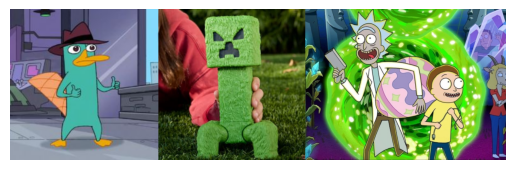

In [4]:
foto_grupo = read_image('static/foto-grupo.jpg')
avatares = read_image('static/avatares.jpg')

show_image(foto_grupo)
show_image(avatares)

In [5]:
DELAY_CAPTION = 1500
DELAY_BLUR = 100
MAX_KERNEL_LENGTH = 31

src = None
dst = None
window_name = 'Smoothing Demo'
kernels = [3, 5, 11, 29]


def display_dst(delay):
    cv2.imshow(window_name, dst)
    c = cv2.waitKey(delay)
    if c >= 0 : return -1
    return 0

def display_caption(caption):
    global dst
    dst = np.zeros(src.shape, src.dtype)
    rows, cols, _ch = src.shape
    cv2.putText(dst, caption,
                (int(cols / 4), int(rows / 2)),
                cv2.FONT_HERSHEY_COMPLEX, 1, (255, 255, 255))

    return display_dst(DELAY_CAPTION)

def mediana(imagem):
    global src
    src = imagem

    if display_caption('Median Blur') != 0:
        return 0

    resultados = {}

    for k in kernels:
        imagem_ruido = cv2.medianBlur(src,k)
        nome_arquivo = f'static/borramento_mediano{k}x{k}.jpg'
        imagem_ruido = cv2.cvtColor(imagem_ruido, cv2.COLOR_BGR2RGB)
        cv2.imwrite(nome_arquivo, imagem_ruido)
        resultados[k] = imagem_ruido
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0
    return imagem_ruido


def gaussian(imagem):
    global src
    src = imagem

    # Aplicando o borramento gausiiano
    if display_caption('Gaussian Blur') != 0:
        return 0

    resultados = {}

    for k in kernels:
        imagem_ruido = cv2.GaussianBlur(src, (k,k), 0)  # tupla (k,k) e sigmaX=0
        nome_arquivo = f'static/borramento_gaussiano{k}x{k}.jpg'
        imagem_ruido = cv2.cvtColor(imagem_ruido, cv2.COLOR_BGR2RGB)
        cv2.imwrite(nome_arquivo, imagem_ruido)
        resultados[k] = imagem_ruido
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0

    return imagem_ruido


def bilateral(imagem):
    global src
    src = imagem

    # aplicando filtro bilateral
    if display_caption('Bilateral Blur') != 0:
        return 0

    resultados = {}

    for k in kernels:
        imagem_ruido = cv2.bilateralFilter(src, k, k*2, k/2)
        nome_arquivo = f'static/borramento_bilateral{k}x{k}.jpg'
        imagem_ruido = cv2.cvtColor(imagem_ruido, cv2.COLOR_BGR2RGB)
        cv2.imwrite(nome_arquivo, imagem_ruido)
        resultados[k] = imagem_ruido
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0

    return imagem_ruido

def media(imagem):
    global src
    src = imagem

    # aplicando filtro de media
    if display_caption('Homogeneous Blur') != 0:
        return 0

    resultados = {}

    for k in kernels:
        imagem_ruido = cv2.blur(src, (k,k))
        nome_arquivo = f'static/borramento_media{k}x{k}.jpg'
        imagem_ruido = cv2.cvtColor(imagem_ruido, cv2.COLOR_BGR2RGB)
        cv2.imwrite(nome_arquivo, imagem_ruido)
        resultados[k] = imagem_ruido
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0

    return imagem_ruido

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


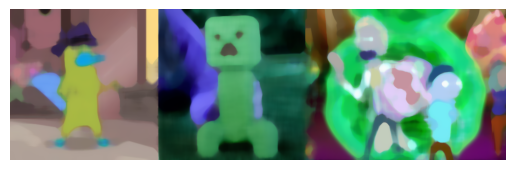

In [6]:
mediana = mediana(avatares)
show_image(mediana)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


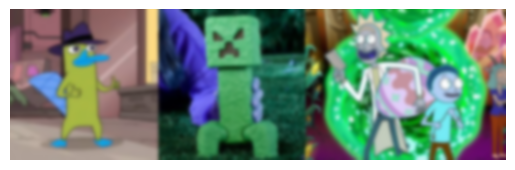

In [7]:
gaussiano = gaussian(avatares)
show_image(gaussiano)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


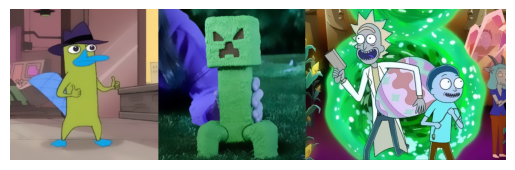

In [8]:
bilateral = bilateral(avatares)
show_image(bilateral)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


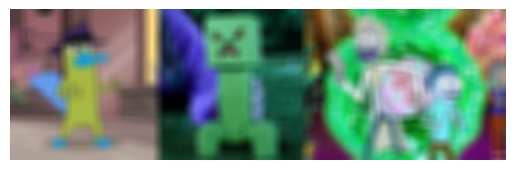

In [9]:
media = media(avatares)
show_image(media)

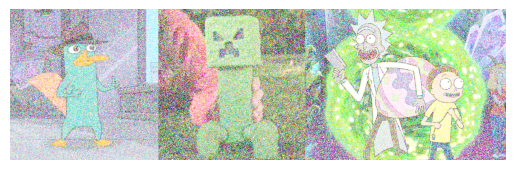

In [9]:
def add_gaussian_noise(imagem, mean=0, std=25):
    noise = np.random.normal(mean,std,imagem.shape).astype(np.uint8)
    noisy_image = cv2.add(imagem, noise)
    return noisy_image

img_ruido = add_gaussian_noise(avatares)
show_image(img_ruido)

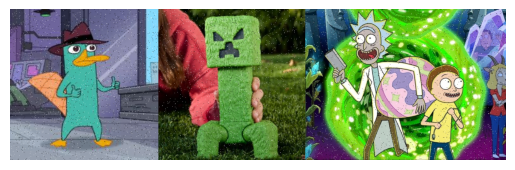

In [10]:
def add_salt_and_pepper_noise(image, noise_ratio=0.02):
    noisy_image = image.copy()
    h, w, c = noisy_image.shape
    noisy_pixels = int(h * w * noise_ratio)

    for _ in range(noisy_pixels):
        row, col = np.random.randint(0, h), np.random.randint(0, w)
        if np.random.rand() < 0.5:
            noisy_image[row, col] = [0, 0, 0]
        else:
            noisy_image[row, col] = [255, 255, 255]

    return noisy_image

img_sal_pimenta = add_salt_and_pepper_noise(avatares)
show_image(img_sal_pimenta)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


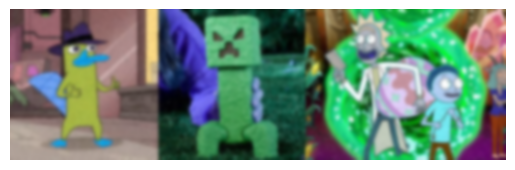

In [11]:
gaussiano_recuperacao = gaussian(img_sal_pimenta)
show_image(gaussiano_recuperacao)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


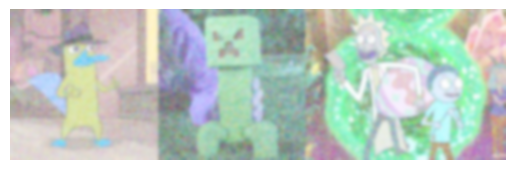

In [12]:
gaussiano = gaussian(img_ruido)
show_image(gaussiano)

In [13]:
def calcular_psnr(I1, I2):
    s1 = cv2.absdiff(I1, I2)
    s1 = np.float32(s1)
    s1 = s1 * s1
    sse = s1.sum()

    # return zero if the difference is extremely small
    if sse <= 1e-10:
        return 0
    else:
        shape = I1.shape
        mse = 1.0 * sse / (shape[0] * shape[1] * shape[2])
        psnr = 10.0 * np.log10((255 * 255) / mse)
        return psnr


def calcular_ssim(I1, I2):
    C1 = 6.5025
    C2 = 58.5225

    # converting to float for squaring
    I1 = np.float32(I1)
    I2 = np.float32(I2)
    I2_2 = I2 * I2
    I1_2 = I1 * I1
    I1_I2 = I1 * I2

    # applying GaussianBlur with (11,11) kernel where mean=st_dev=1.5
    mu1 = cv2.GaussianBlur(I1, (11, 11), 1.5)
    mu2 = cv2.GaussianBlur(I2, (11, 11), 1.5)
    mu1_2 = mu1 * mu1
    mu2_2 = mu2 * mu2
    mu1_mu2 = mu1 * mu2

    sigma1_2 = cv2.GaussianBlur(I1_2, (11, 11), 1.5)
    sigma1_2 -= mu1_2
    sigma2_2 = cv2.GaussianBlur(I2_2, (11, 11), 1.5)
    sigma2_2 -= mu2_2
    sigma12 = cv2.GaussianBlur(I1_I2, (11, 11), 1.5)
    sigma12 -= mu1_mu2

    t1 = 2 * mu1_mu2 + C1
    t2 = 2 * sigma12 + C2
    t3 = t1 * t2
    t1 = mu1_2 + mu2_2 + C1
    t2 = sigma1_2 + sigma2_2 + C2
    t1 = t1 * t2
    ssim_map = cv2.divide(t3, t1)
    ssim = cv2.mean(ssim_map)[0]  # Corrigido: pega só o valor médio (float)
    return ssim

def avaliar_qualidade(imagem_original, imagem_ruidosa):
    psnr_valor = calcular_psnr(imagem_original, imagem_ruidosa)
    ssim_valor = calcular_ssim(imagem_original, imagem_ruidosa)
    return psnr_valor, ssim_valor

def categoriza_qualidade_psnr(valor):
    if valor is None:
        return 'indefinido'

    if valor >= 35:
        return 'qualidade alta'

    elif valor >= 25:
        return 'qualidade média'

    else:
        return 'qualidade baixa'

def categoriza_qualidade_ssim(valor):
    if valor is None:
        return 'indefinido'

    if valor >= 0.95:
        return 'qualidade alta'

    elif valor >= 0.80:
        return 'qualidade média'

    else:
        return 'qualidade baixa'

Tabela de Qualidade (SSIM):


,bilateral,gaussiano,media,mediano
3,0.984055279107961 (qualidade alta),0.298423749168565 (qualidade baixa),0.906513454053225 (qualidade média),0.934609193501115 (qualidade média)
5,0.981368869714264 (qualidade alta),0.347343585948722 (qualidade baixa),0.783006835487840 (qualidade baixa),0.840209066771215 (qualidade média)
11,0.962581366038398 (qualidade alta),0.419495677543120 (qualidade baixa),0.578968880204191 (qualidade baixa),0.675383680633200 (qualidade baixa)
29,0.880630723311507 (qualidade média),0.401940375152660 (qualidade baixa),0.456436266799818 (qualidade baixa),0.516985426016004 (qualidade baixa)


Gráfico de Qualidade (SSIM):


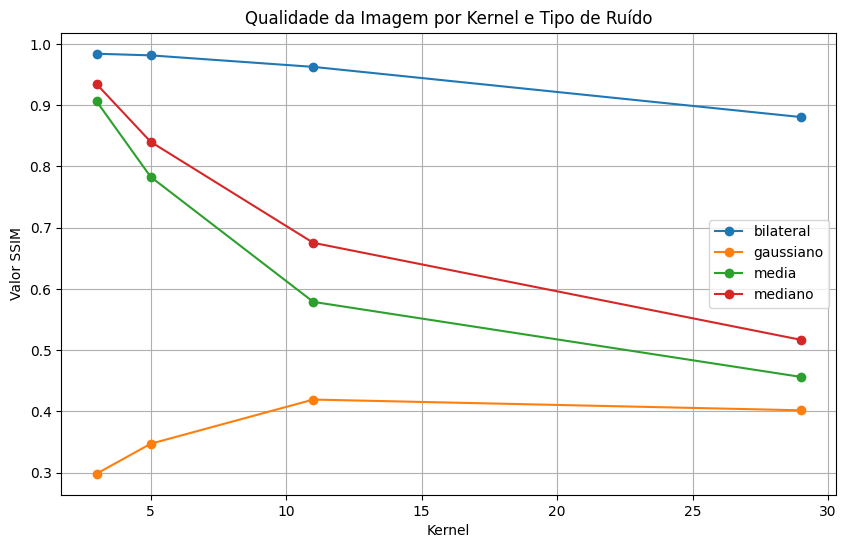

In [14]:
tipos_ruido = ['bilateral', 'gaussiano', 'media', 'mediano']

# Montando a tabela de resultados
resultados_ssim = {}
resultados_psnr = {}
for kernel in kernels:
    linha_ssim = []
    linha_psnr = []
    for ruido in tipos_ruido:
        try:
            path_img = f'static/borramento_{ruido}{kernel}x{kernel}.jpg'
            imagem_ruidosa = read_image(path_img)
            psnr_valor, ssim_valor = avaliar_qualidade(avatares, imagem_ruidosa)
        except Exception as e:
            psnr_valor = None
            ssim_valor = None
        linha_ssim.append(ssim_valor)
        linha_psnr.append(psnr_valor)
    resultados_ssim[kernel] = linha_ssim
    resultados_psnr[kernel] = linha_psnr


# DataFrame com valores numéricos para gráfico (com 15 casas decimais)
df_valores_ssim = pd.DataFrame(resultados_ssim, index=tipos_ruido).T
df_valores_psnr = pd.DataFrame(resultados_psnr, index=tipos_ruido).T

# DataFrame com qualidade categorizada
df_qualidade_ssim = df_valores_ssim.copy().astype(object)
df_qualidade_psnr = df_valores_psnr.copy().astype(object)

for kernel in kernels:
    for ruido in df_qualidade_ssim.columns:
        valor_ssim = df_qualidade_ssim.loc[kernel, ruido]
        categoria_ssim = categoriza_qualidade_ssim(valor_ssim)

        valor_psnr = df_qualidade_psnr.loc[kernel, ruido]
        categoria_psnr = categoriza_qualidade_psnr(valor_psnr)

        if valor_ssim is not None:
            df_qualidade_ssim.loc[kernel, ruido] = f'{valor_ssim:.15f} ({categoria_ssim})'
        else:
            df_qualidade_ssim.loc[kernel, ruido] = 'indefinido'

        if valor_psnr is not None:
            df_qualidade_psnr.loc[kernel, ruido] = f'{valor_psnr:.15f} ({categoria_psnr})'
        else:
            df_qualidade_psnr.loc[kernel, ruido] = 'indefinido'


# Exibindo tabela com qualidade
print("Tabela de Qualidade (SSIM):")
display(df_qualidade_ssim)

print("Gráfico de Qualidade (SSIM):")
# Plotando gráfico com escala ajustada
plt.figure(figsize=(10,6))
for ruido in df_valores_ssim.columns:
    plt.plot(df_valores_ssim.index, df_valores_ssim[ruido], marker='o', label=ruido)
plt.xlabel('Kernel')
plt.ylabel('Valor SSIM')
plt.title('Qualidade da Imagem por Kernel e Tipo de Ruído')
plt.legend()
plt.grid(True)
plt.show()

Tabela de Qualidade (PSNR):


,bilateral,gaussiano,media,mediano
3,40.136711120605469 (qualidade alta),9.148782730102539 (qualidade baixa),27.093097686767578 (qualidade média),28.695095062255859 (qualidade média)
5,39.718395233154297 (qualidade alta),9.215048789978027 (qualidade baixa),23.919300079345703 (qualidade baixa),24.475967407226562 (qualidade baixa)
11,37.132450103759766 (qualidade alta),9.232789993286133 (qualidade baixa),20.878980636596680 (qualidade baixa),21.644996643066406 (qualidade baixa)
29,30.027124404907227 (qualidade média),9.110239982604980 (qualidade baixa),17.602718353271484 (qualidade baixa),18.113449096679688 (qualidade baixa)


Gráfico de Qualidade (PSNR):


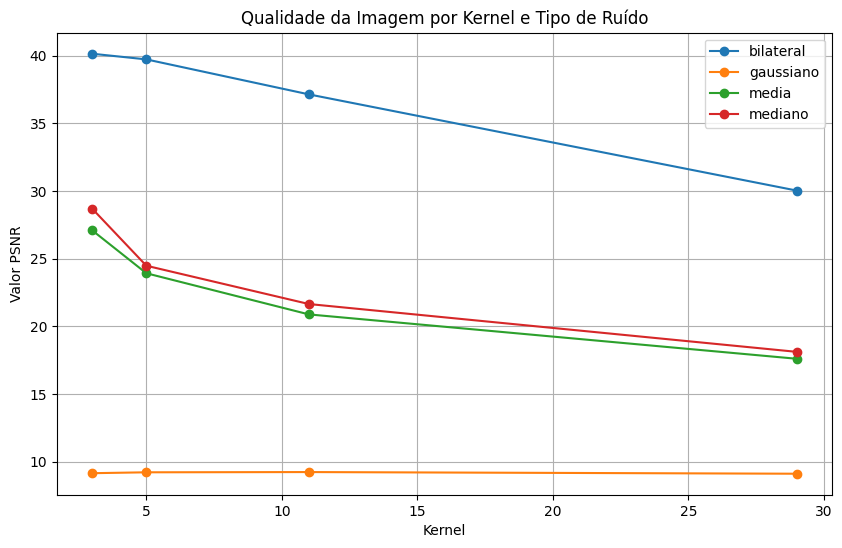

In [15]:
print("Tabela de Qualidade (PSNR):")
display(df_qualidade_psnr)

print("Gráfico de Qualidade (PSNR):")
# Plotando gráfico com escala ajustada
plt.figure(figsize=(10,6))
for ruido in df_valores_psnr.columns:
    plt.plot(df_valores_psnr.index, df_valores_psnr[ruido], marker='o', label=ruido)
plt.xlabel('Kernel')
plt.ylabel('Valor PSNR')
plt.title('Qualidade da Imagem por Kernel e Tipo de Ruído')
plt.legend()
plt.grid(True)
plt.show()

# Comparação entre os filtros passa-baixa aplicados

### Filtro de Média (Box Filter)
O filtro de média é o mais simples dos quatro avaliados. Ele substitui cada pixel pela média aritmética de todos os vizinhos dentro da janela, tratando todos com o mesmo peso. Nos kernels menores (3×3 e 5×5), o efeito é uma suavização discreta que já reduz ruídos de alta frequência sem comprometer demais a legibilidade da imagem as bordas dos personagens ainda se mantêm reconhecíveis e o contraste geral é preservado. Ao avançar para o kernel 11×11, a suavização se torna claramente perceptível: as texturas finas desaparecem e há uma perda sensível de nitidez nas transições. No extremo do 29×29, o resultado é um borrão bastante agressivo, com um característico efeito "plástico" nas regiões de contorno, onde a média entre pixels de cores muito distintas gera transições artificialmente graduais. A principal limitação do filtro de média é exatamente essa incapacidade de distinguir bordas de ruído tudo é suavizado da mesma maneira.

### Filtro Gaussiano
O filtro gaussiano é uma evolução direta do filtro de média. Em vez de pesos uniformes, ele aplica uma função gaussiana bidimensional ao kernel, de modo que os pixels mais próximos ao centro contribuem mais para o resultado final. Isso produz uma suavização visivelmente mais natural e orgânica em todos os tamanhos de kernel. Nos tamanhos 3×3 e 5×5, a diferença em relação ao filtro de média é quase imperceptível a olho nu, mas já se nota uma ligeira superioridade na preservação das bordas. Com o kernel 11×11, o gaussiano mantém uma coerência visual que o filtro de média já havia perdido. No 29×29, embora o borrão seja intenso, o resultado ainda parece mais fotográfico e menos artificial do que o equivalente do filtro de média, porque a transição entre zonas nítidas e borradas é mais suave e não gera halos tão pronunciados. O gaussiano é, de longe, o mais utilizado em pré-processamento de imagens justamente por esse equilíbrio entre eficiência computacional e qualidade visual.

### Filtro Mediano
O filtro mediano é o único dos quatro que é não-linear, ele substitui cada pixel pelo valor mediano de sua vizinhança. Isso confere a ele uma propriedade muito especial: resistência excepcional ao ruído do tipo salt-and-pepper, eliminando picos extremos de intensidade sem criar os gradientes artificiais que os filtros lineares produzem. Nos kernels pequenos (3×3 e 5×5), é possível observar um efeito visual interessante que lembra uma posterização suave ou uma estética de ilustração cartoon, pois as regiões de cor uniforme se tornam ainda mais homogêneas enquanto as bordas se mantêm bem definidas. Com o kernel 11×11, esse efeito cartoon se intensifica bastante, e as texturas finas como os detalhes do Creeper do Minecraft ou os contornos do fundo começam a ser destruídas. No 29×29, o resultado é quase uma pintura abstrata: a imagem perde a maior parte do seu conteúdo de textura e assume grandes blocos de cor uniforme. Apesar de sua excelência para remoção de ruído impulsivo, o filtro mediano se torna inadequado para kernels grandes em imagens com alto nível de detalhe.

### Filtro Bilateral
O filtro bilateral é o mais sofisticado dos quatro e o que apresenta o melhor desempenho qualitativo em todos os tamanhos de kernel. Sua grande inovação é combinar dois critérios de ponderação simultaneamente: a distância espacial entre os pixels (como no gaussiano) e a semelhança fotométrica, ou seja, a diferença de intensidade entre os pixels vizinhos. Na prática, isso significa que pixels próximos mas com cores muito diferentes como acontece numa borda entre um personagem e o fundo recebem peso baixo, sendo efetivamente excluídos da média. O resultado é que as bordas são preservadas com uma nitidez notável mesmo em kernels maiores. Nos tamanhos 3×3 e 5×5, a imagem resultante é quase indistinguível do original, com uma suavização que age apenas nas regiões planas e uniformes. No kernel 11×11, a suavização já é claramente visível mas as bordas ainda estão presentes com boa fidelidade. No 29×29, o efeito se aproxima de um estilo de fotografia com desfoque de pele (skin smoothing), algo muito usado em edição de retratos. A única desvantagem prática é o custo computacional: o filtro bilateral é ordens de magnitude mais lento que os demais, o que limita seu uso em aplicações em tempo real sem otimizações específicas.

### Considerações técnicas finais sobre a filtragem passa-baixa
Do ponto de vista técnico, a filtragem passa-baixa é uma ferramenta indispensável em processamento de imagens, mas sua utilidade depende fortemente do objetivo da aplicação. Quando o objetivo é remover ruído gaussiano antes de uma etapa de segmentação ou detecção de bordas, o filtro gaussiano com kernel pequeno (3×3 ou 5×5) é a escolha mais adequada, pois reduz as altas frequências indesejadas sem comprometer as estruturas importantes. Quando o ruído é do tipo impulsivo (salt-and-pepper), o filtro mediano com kernel pequeno supera todos os outros, sendo a única opção que remove os picos sem introduzir gradientes artificiais. Quando a prioridade é a qualidade estética por exemplo, em edição de imagens, compressão com perda ou efeitos visuais o filtro bilateral é o mais indicado por ser o único capaz de suavizar e preservar bordas simultaneamente.
Em todos os casos, fica evidente que o aumento do tamanho do kernel amplifica indiscriminadamente o efeito do filtro. Kernels muito grandes (como o 29×29 testado) raramente fazem sentido em aplicações práticas que exigem fidelidade à imagem original, sendo mais úteis em contextos de segmentação grosseira ou geração de efeitos artísticos. O ponto de equilíbrio entre supressão de ruído e preservação de estrutura costuma estar nos kernels de 3×3 a 7×7, dependendo da resolução da imagem e da natureza do ruído presente.

# Parte 2

In [ ]:
import numpy as np
import cv2

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Cannot open camera")
    exit()

while True:

    ret, frame = cap.read()

    if not ret:
        print("Can't receive frame")
        break

    # pior resultado: gaussiano
    filtro_gaussiano = cv2.GaussianBlur(frame, (29,29), 0)

    # melhor resultado: bilateral
    filtro_bilateral = cv2.bilateralFilter(frame, 3, 6, 1.5)

    cv2.imshow("Original", frame)
    cv2.imshow("Gaussian (pior)", filtro_gaussiano)
    cv2.imshow("Bilateral (melhor)", filtro_bilateral)

    key = cv2.waitKey(1)

    if key == ord('q'):
        break

    if key == ord('s'):
        cv2.imwrite("static/webcam/gaussiano_3x3.jpg", filtro_gaussiano)
        cv2.imwrite("static/webcam/bilateral_3x3.jpg", filtro_bilateral)
        print("Imagens salvas")

cap.release()
cv2.destroyAllWindows()

# Parte 3




In [ ]:
import cv2
import numpy as np

tamanho_kernel = 3
tipo_filtro = 'm'   # 'a' = media, 'g' =  gaussiano, 'm'= mediana, 'b' = bilateral
tipo_ruido = 'o'    # 'o'= sem ruido, 'y' = gaussiano, 'p' = sal-e-pimenta

janela = 'Webcam Filter'
cv2.namedWindow(janela)

print("=== Comandos ===")
print("Filtros: [a] Media | [g] Gaussiano | [m] Mediana | [b] Bilateral")
print("Kernel:  [3] 3x3 | [5] 5x5 | [7] 11x11 | [9] 29x29 | [x] 47x47")
print("Ruido:   [o] Sem ruido | [y] Gaussiano | [p] Sal-e-pimenta")
print("ESC para sair")

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Webcam not found")
else:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        #aplica ruido se precisar
        img_processada = frame.copy()
        if tipo_ruido == 'y':  # Gaussiano
            noise = np.random.normal(0, 25, frame.shape).astype(np.uint8)
            img_processada = cv2.add(frame, noise)
        elif tipo_ruido == 'p':  # Sal-e-pimenta
            s_vs_p = 0.5
            amount = 0.004
            out = np.copy(frame)
            num_salt = np.ceil(amount * frame.size * s_vs_p)
            coords = [np.random.randint(0, i-1, int(num_salt)) for i in frame.shape]
            out[coords[0], coords[1], :] = 255
            num_pepper = np.ceil(amount * frame.size * (1. - s_vs_p))
            coords = [np.random.randint(0, i-1, int(num_pepper)) for i in frame.shape]
            out[coords[0], coords[1], :] = 0
            img_processada = out

        # aplica filtro qie foi escolhido
        if tipo_filtro == 'a':  # media
            resultado = cv2.blur(img_processada, (tamanho_kernel, tamanho_kernel))
            nome_filtro = "Media"
        elif tipo_filtro == 'g':  # gaussiano
            resultado = cv2.GaussianBlur(img_processada, (tamanho_kernel, tamanho_kernel), 0)
            nome_filtro = "Gaussiano"
        elif tipo_filtro == 'm':  # mediana
            resultado = cv2.medianBlur(img_processada, tamanho_kernel)
            nome_filtro = "Mediana"
        elif tipo_filtro == 'b':  # bilateral
            resultado = cv2.bilateralFilter(img_processada, tamanho_kernel, 75, 75)
            nome_filtro = "Bilateral"
        else:
            resultado = img_processada
            nome_filtro = "?"

        # mostra info na tela
        info = f"{nome_filtro} | Kernel {tamanho_kernel}x{tamanho_kernel} | "
        info += "Sem ruido" if tipo_ruido == 'o' else "Ruido Gaussiano" if tipo_ruido == 'y' else "Sal-e-pimenta"
        cv2.putText(resultado, info, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        cv2.imshow(janela, resultado)

        key = cv2.waitKey(1) & 0xFF

        if key == 27:
            break
        #Filtros
        elif key == ord('a'): tipo_filtro = 'a'; print("Filtro: Media")
        elif key == ord('g'): tipo_filtro = 'g'; print("Filtro: Gaussiano")
        elif key == ord('m'): tipo_filtro = 'm'; print("Filtro: Mediana")
        elif key == ord('b'): tipo_filtro = 'b'; print("Filtro: Bilateral")
        # Kernels
        elif key == ord('3'): tamanho_kernel = 3; print(f"Kernel: {tamanho_kernel}")
        elif key == ord('5'): tamanho_kernel = 5; print(f"Kernel: {tamanho_kernel}")
        elif key == ord('7'): tamanho_kernel = 11; print(f"Kernel: {tamanho_kernel}")
        elif key == ord('9'): tamanho_kernel = 29; print(f"Kernel: {tamanho_kernel}")
        elif key == ord('x'): tamanho_kernel = 47; print(f"Kernel: {tamanho_kernel}")
        # ruidos
        elif key == ord('o'): tipo_ruido = 'o'; print("Ruido: Sem ruido")
        elif key == ord('y'): tipo_ruido = 'y'; print("Ruido: Gaussiano")
        elif key == ord('p'): tipo_ruido = 'p'; print("Ruido: Sal-e-pimenta")

cap.release()
cv2.destroyAllWindows()